In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import uproot as rt
import scipy.optimize as scp

In [2]:

def readRootFile(input_path):
    with rt.open(input_path) as file:
        OpticksHits=file["OpticksHits"].arrays(library="np")
        G4Hits=file["Geant4Hits"].arrays(library="np")
        PhotonInfo=file["PhotonInfo"].arrays(library="np")
    return OpticksHits , G4Hits ,PhotonInfo
    
def rewrite_geant4_csv_header(input_path, output_path):
    with open(input_path, 'r') as infile:
        lines = infile.readlines()

    # Extract column names from metadata
    column_names = []
    data_start_index = 0
    for i, line in enumerate(lines):
        if line.startswith("#column"):
            match = re.match(r"#column\s+\w+\s+(\w+)", line)
            if match:
                column_names.append(match.group(1))
        elif not line.startswith("#"):
            data_start_index = i
            break

    # Write new file with standard header
    with open(output_path, 'w') as outfile:
        outfile.write(",".join(column_names) + "\n")  # new header
        for line in lines[data_start_index:]:
            outfile.write(line)

def Getinfo(f1,f2):
    if(f1!=""):
        rewrite_geant4_csv_header(f1,f2)
    return pd.read_csv(f2)

def FitHist1D(hist,ax,label,clr,ap,width=3,linstyle="-"):
    ## Locate Min and Max
    MinAndMaxMask=(hist[0]>=(np.mean(hist[0])*0.1)) & (hist[0]<=np.max(hist[0])*0.9)
    
    initials=(np.max(hist[0]),np.mean(hist[1][:-1][MinAndMaxMask]),np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    #initials=(np.max(hist[0]),0,np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    print(f"Initials {initials}")
    fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials,maxfev=5000)
    String_=label+r'$\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    if(ax):
        ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,linestyle=linstyle,alpha=ap,linewidth=width)
    FitValues={"Amp":round(fit[0][0],2),"u":round(fit[0][1],2),"sigma":abs(round(fit[0][2],2)),"offset":round(fit[0][3],2)}
    print(FitValues)
    return FitValues    
    
def Plot1D_KDE(valO,ValG4,FileName,Title,Binsize=200,labelx="x",isPlottext=False,isHistType="numpy",opacity=1,fontsize=30,width=5,lbl="x(mm)",tp="diff"):
    maXX = np.max(np.array([np.max(ValG4),np.max(valO)]))
    miNX = np.min(np.array([np.min(ValG4),np.min(valO)]))
    lins1X = np.linspace(miNX,maXX,Binsize)
    fig, ax = plt.subplots(2, 1, figsize=(25, 15), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    x = 0
    y = 0
    if(isPlottext):
        if(isHistType=="numpy"):
            x = np.histogram(ValG4, bins=lins1X)
        else:
            x = plt.hist(ValG4, bins=lins1X)
        h1=ax[0].hist(ValG4,color="red",label="Geant4",bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    else:
        #sns.histplot(data=G4Dict,x=lbl,color="orange",label="Geant4",bins=Binsz,kde=False,element="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
        h1=ax[0].hist(ValG4,color="red",label="Geant4",bins=lins1X,histtype="step",fill=False,linestyle="-",linewidth=width,alpha=opacity);
    
    x=0
    y=0
    fitx=0
    fity=0
    
    if(isPlottext):
        binX = np.linspace(np.min(valO[0]) , np.max(valO[0]) , Binsize)
        if(isHistType=="numpy"):
            x = np.histogram(valO[0], bins=binX)
        else:
            x = np.histogram(valO[0], bins=binX)
        h2=ax[0].hist(valO,color="green",label="Opticks",bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);
    else:    
        #sns.histplot(data=OpticksDict,x=lbl,color="blue",label="Opticks",bins=Binsz,kde=False,element="step",fill=False,linestyle="--",linewidth=width,alpha=opacity)
        h2=ax[0].hist(valO,color="green",label="Opticks",bins=lins1X,histtype="step",fill=False,linestyle="--",linewidth=width,alpha=opacity);

    #Ratio Plot    
    # Calculate histogram counts for ratio plot - MUST use same bins
    counts1,bin_edges,_ = h1
    counts2,_,_ = h2 # Use the same bin_edges

    # Calculate bin centers for plotting the ratio
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    numerator_val = 0
    combinedarray = 0
    denominator_val = 0
    result=[]
    res_err=[]
    label=""
    ylabel=""
    xlabel=""
   
    
    if(tp == "diff"):
        label="Difference"
        ylabel="diff / max"
        xlabel=labelx
        numerator_val = counts2 - counts1
        combinedarray = np.concatenate((counts1, counts2))
        denominator_val = 1#np.max(combinedarray)
        
        eps = 1e-12
        numerator_val = np.where(np.abs(numerator_val) < eps, eps, numerator_val)
        denominator_val = np.where(np.abs(denominator_val) < eps, eps, denominator_val)
        result  = numerator_val / denominator_val
        error_numerator = np.sqrt(counts1 + counts2)
        error_denominator = np.sqrt(counts1) # <-- The error from the value you divide by
        res_err = np.abs(result) * np.sqrt((error_numerator / numerator_val)**2 +(error_denominator / denominator_val)**2)        
    elif( tp == "ratio"):
        label="Ratio G4/Opticks"
        ylabel="Ratio"
        xlabel=labelx
        # Poisson errors (or replace with your own errors)
        err1 = np.sqrt(counts1)
        err2 = np.sqrt(counts2)

        # ratio
        result  = counts2 / counts1
        # propagated error
        res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)
    if(len(result)<1):
        print (f"Check type {tp}, vector does not have any element")
        return
 
    #error_numerator = np.sqrt(counts1 + counts2)
    #error_denominator = np.sqrt(counts1) # <-- The error from the value you divide by
    
  

    # Use scientific notation for the axis 
    ax[0].ticklabel_format(axis='y', style='sci', scilimits=(4,4))
    ax[0].tick_params(axis='both',which="major",labelsize=fontsize+10)
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)


    ax[0].set_ylabel("Frequency",fontsize=fontsize+10)
    #ax[0].set_xlabel(lbl,fontsize=fontsize+10)
    ax[0].yaxis.get_offset_text().set_size(fontsize+10) # Adjust the font size here
    ax[0].legend(fontsize=fontsize)   
    ax[0].set_title(Title,fontweight="bold",ha="center",fontsize=fontsize+20)
    ax[0].semilogy()
    
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    
    print (f" Size Bin_Centers is {len(bin_centers)}")
    print (f" Size result {len(result)} min, max {np.max(result)} , {np.min(result)}")    
    print (f" Size res_err {len(res_err)} min, max {np.max(res_err)} , {np.min(res_err)}")    
    
    #ax[1].plot(bin_centers, ratio, marker='o', linestyle='-', color='black', markersize=5)
    ax[1].errorbar(bin_centers, result, yerr=res_err, fmt='o', color='black',
                    markersize=5, capsize=3, elinewidth=1, label=label) # fmt='o' for points
    ax[1].axhline(1, color='grey', linestyle='--', linewidth=1)
    ax[1].set_xlabel(xlabel,fontsize=fontsize+10)
    ax[1].set_ylabel(ylabel,fontsize=(fontsize+10))
    ax[1].grid(True, linestyle=':', alpha=0.6)
    #ax[1].set_ylim(-np.max(res_err),np.max(res_err))
    #print(f"result {result}")
    #print(f"res_err {res_err}")
    #ax[1].semilogy()
    #ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0.01,0.01))
    ax[1].tick_params(axis='both',which="major",labelsize=fontsize+10)
    
def Gauss1DSkew(x,Ampl,mean,sigma,a,offset):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma+a*(x-mean))**2))+offset    

In [3]:
## Reading Root files
#file="voxelTest.root"
file="voxelTest_Ray_Abs_v6_1x2x6.root"
#file="voxelTest_Ray_Abs_.root"
FName=f"/home/rice/Projects/DUNE_Opticks/OlderG4OpticksGDML/{file}"
OptResult,G4Result,PhotonInfo=readRootFile(FName)

In [4]:
G4Result.keys()

dict_keys(['evtID', 'SensorID', 'SensorName', 'x', 'y', 'z', 't', 'wavelength', 'ProcessID'])

In [5]:
OptX=OptResult['x']/10
OptY=OptResult['y']/10
OptZ=OptResult['z']/10
OptT=OptResult['t']
OptW=OptResult['wavelength']
OptSID=OptResult['SensorID']
OptevtID=OptResult['evtID']

G4evtID=G4Result["evtID"]
G4X=G4Result['x']/10
G4Y=G4Result['y']/10
G4Z=G4Result['z']/10
G4T=G4Result['t']
G4W=G4Result['wavelength']
G4SID=G4Result['SensorID']

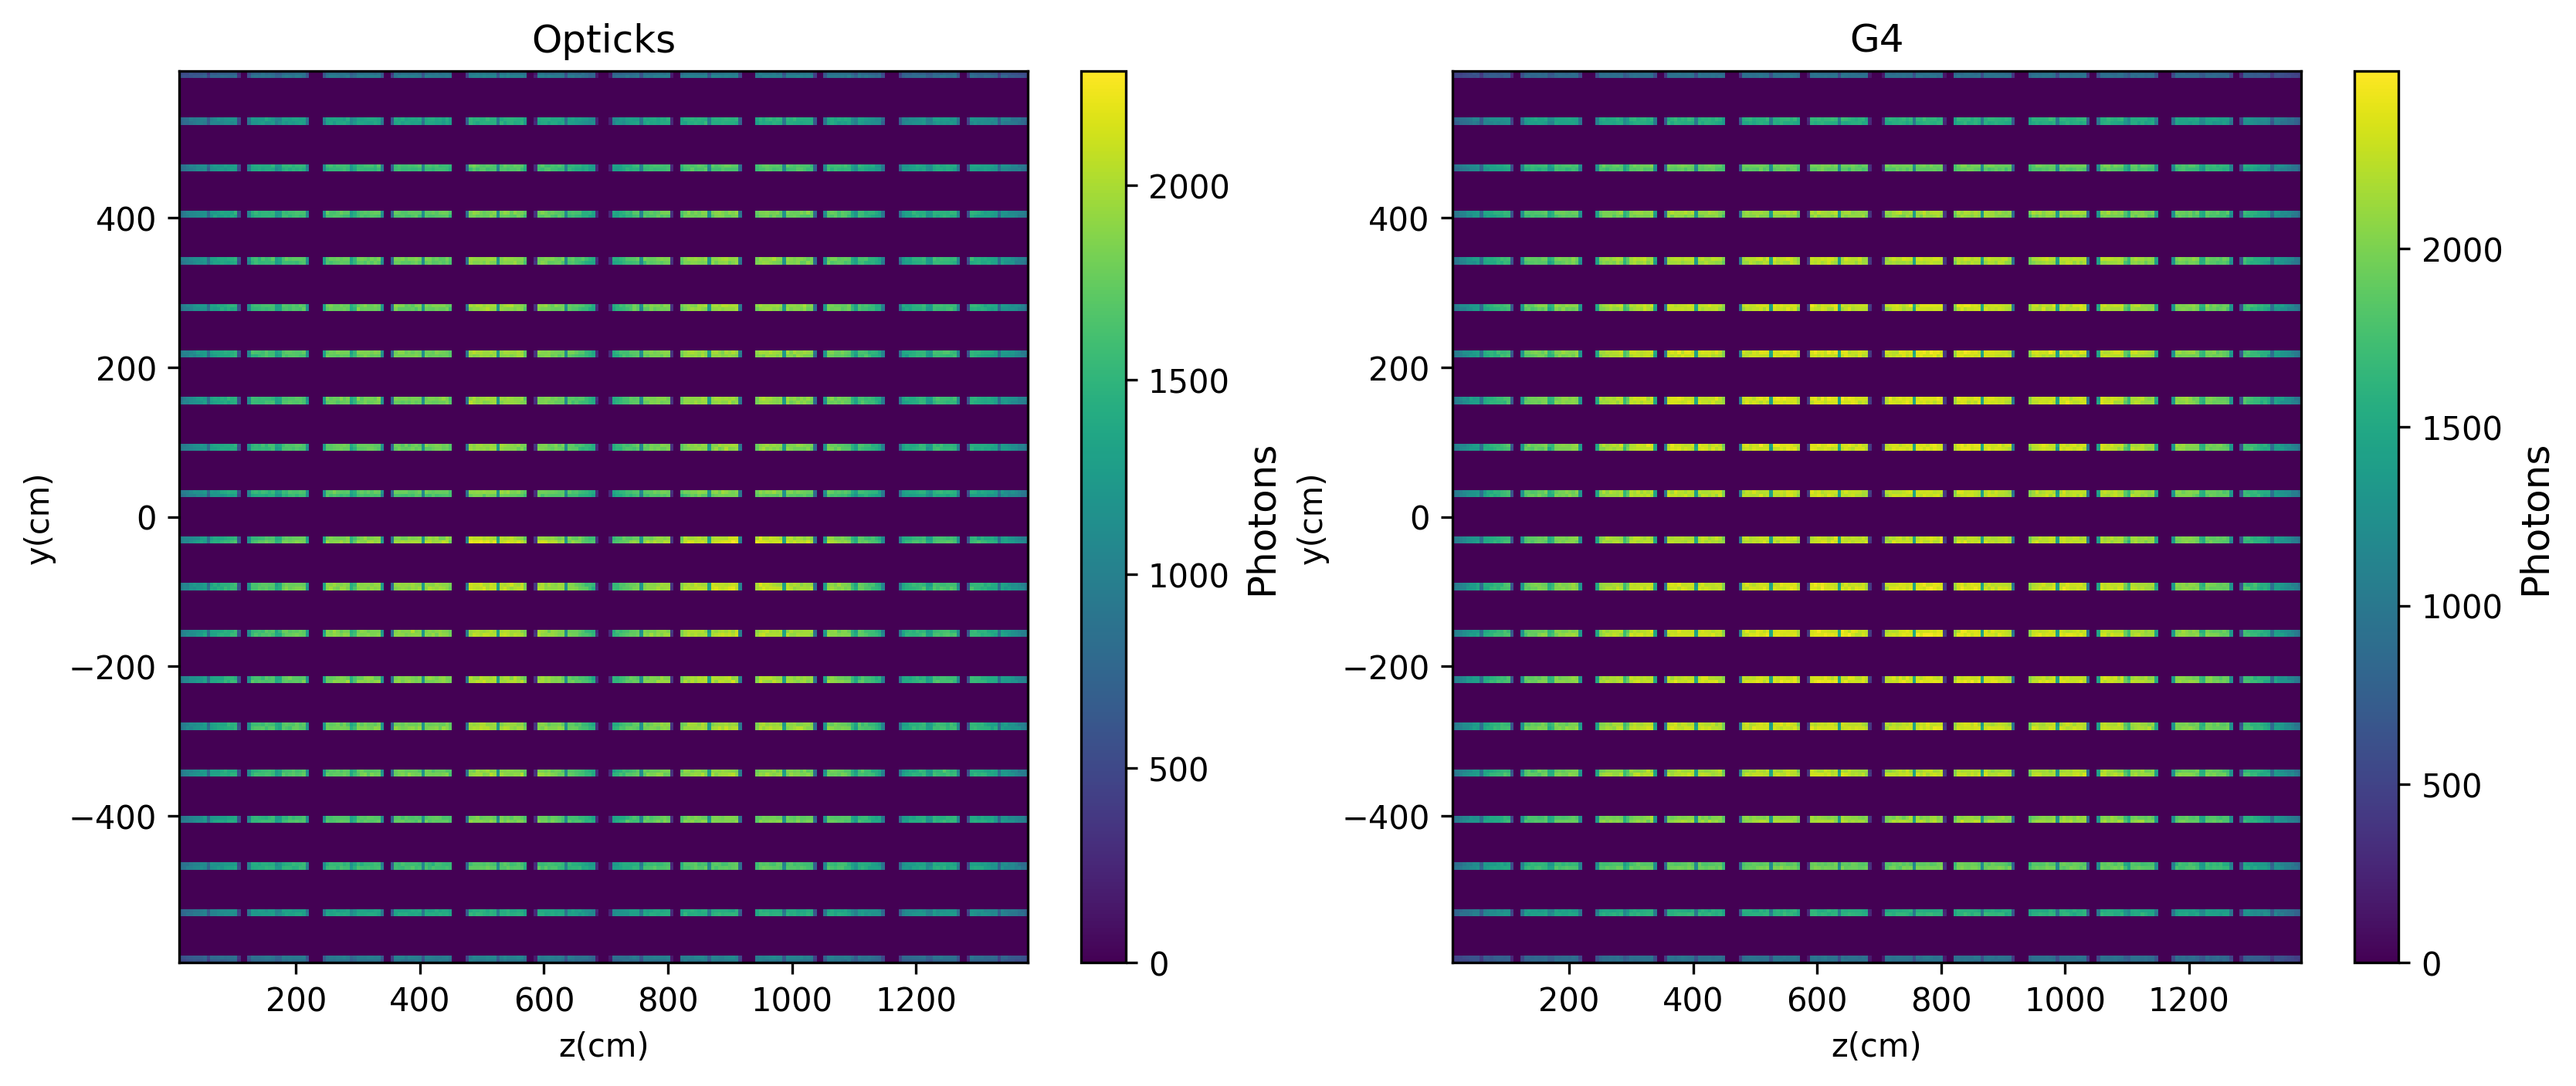

In [21]:
c=5000
b=250

Zmin = min(OptZ.min(), G4Z.min())
Zmax = max(OptZ.max(), G4Z.max())
Ymin = min(OptY.min(), G4Y.min())
Ymax = max(OptY.max(), G4Y.max())
zbins = np.linspace(Zmin , Zmax ,b)
ybins = np.linspace(Ymin , Ymax , b)
fig,p=plt.subplots(1,2,dpi=300,figsize=(13,5))
p[0].set_title("Opticks")
h1=p[0].hist2d(OptZ,OptY,bins=[zbins,ybins],cmin=0,cmax=c,cmap="viridis",label="Opticks")
cbar1=fig.colorbar(h1[3])
cbar1.set_label("Photons", fontsize=12)
p[1].set_title("G4")
h2=p[1].hist2d(G4Z,G4Y,bins=[zbins,ybins],cmin=0,cmax=c,cmap="viridis",label="Geant4")
cbar2=fig.colorbar(h2[3])
cbar2.set_label("Photons", fontsize=12)
for i in range(0,2):
    p[i].set_xlabel("z(cm)")
    p[i].set_ylabel("y(cm)")


/tmp/rice/opticks/ipykernel_3204377/2642682506.py:3: RuntimeWarning: invalid value encountered in divide
  hr3=h1[0]/h2[0]


Text(0, 0.5, 'y(cm)')

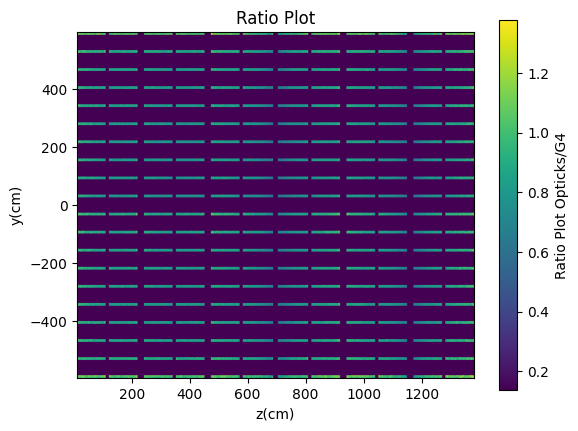

In [22]:
from matplotlib.colors import LogNorm

hr3=h1[0]/h2[0]

hr3 = np.nan_to_num(hr3, nan=0.0, posinf=0.0, neginf=0.0)

plt.title("Ratio Plot")
#plt.imshow(np.rot90(np.flip(h3,axis=1)),origin="lower",cmap="viridis",extent=[Zmin,Zmax,Ymin,Ymax])

_=plt.imshow(np.rot90(np.flip(hr3,axis=1)),origin="lower",cmap="viridis",vmin=np.max(hr3)*0.1, vmax=np.max(hr3),extent=[Zmin,Zmax,Ymin,Ymax])
plt.colorbar(label="Ratio Plot Opticks/G4")
plt.xlabel("z(cm)")
plt.ylabel("y(cm)")

/tmp/rice/opticks/ipykernel_3204377/116690972.py:1: RuntimeWarning: invalid value encountered in divide
  h3=(h1[0]-h2[0])/h2[0]


Text(0, 0.5, 'y(cm)')

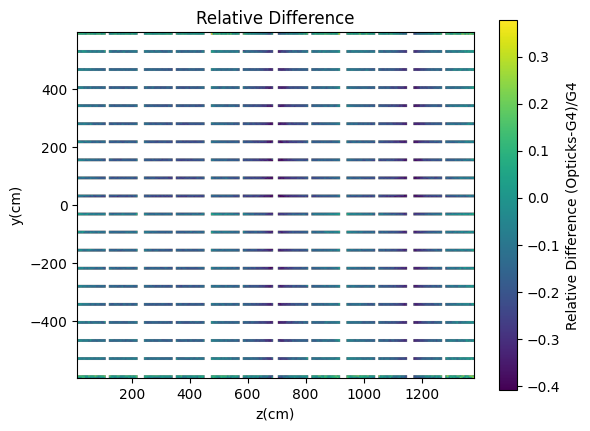

In [8]:
h3=(h1[0]-h2[0])/h2[0]
plt.title("Relative Difference")
plt.imshow(np.rot90(np.flip(h3,axis=1)),origin="lower",cmap="viridis",extent=[Zmin,Zmax,Ymin,Ymax])
plt.colorbar(label="Relative Difference (Opticks-G4)/G4")
plt.xlabel("z(cm)")
plt.ylabel("y(cm)")

1.9127031463697084


/tmp/rice/opticks/ipykernel_3204377/2144210070.py:3: RuntimeWarning: invalid value encountered in divide
  h3=(Hopt-Hg4)/np.sqrt(Hg4+Hopt)


Text(0, 0.5, 'y(cm)')

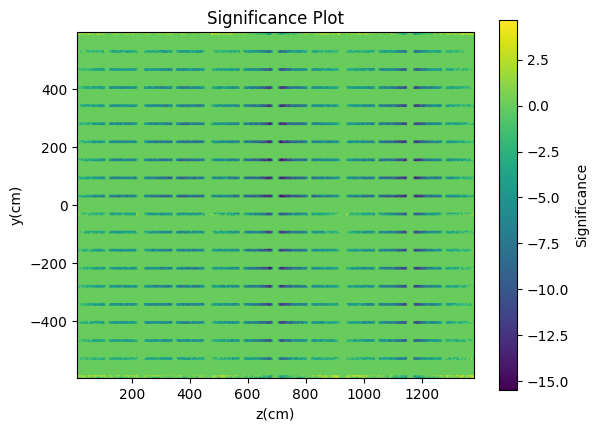

In [9]:
Hopt=h1[0]
Hg4=h2[0]
h3=(Hopt-Hg4)/np.sqrt(Hg4+Hopt)

mask = (Hopt + Hg4) > 10 
pull_masked = np.where(mask, h3, np.nan)    
h4=np.rot90(np.flip(pull_masked,axis=1))
h4 = np.nan_to_num(h4, nan=0.0, posinf=0.0, neginf=0.0)
print(np.mean(h4[(h4>1) & (h4<np.max(h4)*0.95)]))
plt.title("Significance Plot")
plt.imshow(h4,origin="lower",cmap="viridis",extent=[Zmin,Zmax,Ymin,Ymax],)
plt.colorbar(label="Significance")
plt.xlabel("z(cm)")
plt.ylabel("y(cm)")

In [10]:
np.rot90(np.flip(pull_masked,axis=1))

array([[ 0.66911564, -0.06408413, -0.11995203, ...,  0.45920758,
         1.14238891,  3.50678336],
       [ 2.79078153,  2.18226666,  2.27066779, ...,  3.38381685,
         3.72528188,  2.10094327],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 3.00063789,  1.78489235,  1.32785761, ...,  3.48569753,
         2.5869495 ,  1.98457164],
       [ 1.61680869,  0.83844463,  0.94025871, ..., -0.21551218,
         1.80520811,  1.14070365]], shape=(249, 249))

Text(0.5, 0, 'Time (ns)')

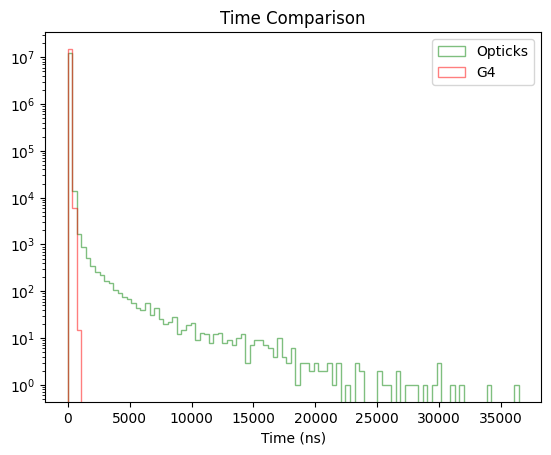

In [11]:
Timemin = min(OptT.min(), G4T.min())
Timemax = max(OptT.max(), G4T.max())
xbins = np.linspace(Timemin , Timemax , 100)

#plt.figure(figsize=(8,4),dpi=300)
plt.title("Time Comparison")
h1=plt.hist(OptT, bins=xbins, alpha=0.5, label="Opticks",histtype="step",color="green")
h2=plt.hist(G4T, bins=xbins, alpha=0.5, label="G4",histtype="step",color="red")
plt.legend()
#plt.loglog()
plt.semilogy()
plt.xlabel("Time (ns)")

Text(0.5, 0, 'Wavelength (nm)')

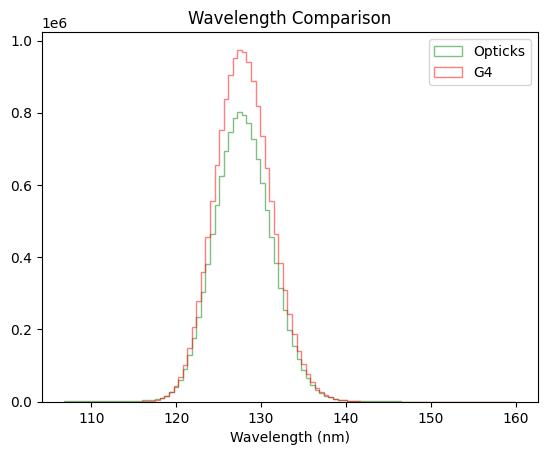

In [12]:
Wmin = min(OptW.min(), G4W.min())
Wmax = max(OptW.max(), G4W.max())
xbins = np.linspace(Wmin , Wmax , 100)

#plt.figure(figsize=(8,4),dpi=300)
plt.title("Wavelength Comparison")
h1=plt.hist(OptW, bins=xbins, alpha=0.5, label="Opticks",histtype="step",color="green")
h2=plt.hist(G4W, bins=xbins, alpha=0.5, label="G4",histtype="step",color="red")
plt.legend()
#plt.loglog()
#plt.semilogy()
plt.xlabel("Wavelength (nm)")

Text(0.5, 0, 'Optical Detectors')

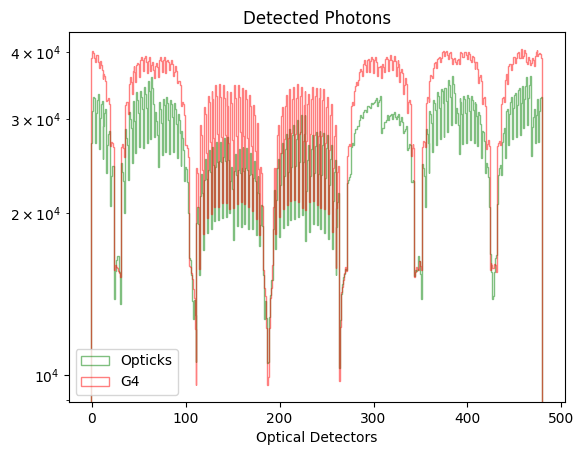

In [13]:
SIDmin = min(OptSID.min(), G4SID.min())
SIDmax = max(OptSID.max(), G4SID.max())
xbins = np.arange(SIDmin-0.5 , SIDmax+1.5 , 1)

#plt.figure(figsize=(8,4),dpi=300)
plt.title("Detected Photons")
h1=plt.hist(OptSID, bins=xbins, alpha=0.5, label="Opticks",histtype="step",color="green")
h2=plt.hist(G4SID, bins=xbins, alpha=0.5, label="G4",histtype="step",color="red")
plt.legend()
#plt.loglog()
plt.semilogy()
plt.xlabel("Optical Detectors")

In [14]:
def GetVisibility(evts,SIDs,phcount):
    ## External Visibility Computation
    ## This can be used for StandAlone Code
    uniqueEvtIDs,counts=np.unique(evts,return_counts=True)
    uniqueSIDs,Sidcounts=np.unique(SIDs,return_counts=True)
    Visibility = {}
    VisArray = np.array([])
    SID = np.array([])
    for evt in uniqueEvtIDs:
        eventMask=evt==evts
        MaskedEvents=evts[eventMask]
        MaskedSIds=SIDs[eventMask]
        uniqueSIDs,Sidcounts=np.unique(MaskedSIds,return_counts=True)
        vis=Sidcounts/phcount
        Visibility[evt]=[uniqueSIDs,vis]
        VisArray=np.append(VisArray,vis)
        SID=np.append(SID,uniqueSIDs)
    return VisArray,SID    

In [15]:
OVisibility=GetVisibility(OptevtID,OptSID,1e5)
G4Visibility=GetVisibility(G4evtID,G4SID,1e5) 

Text(0.5, 0, 'Visibility')

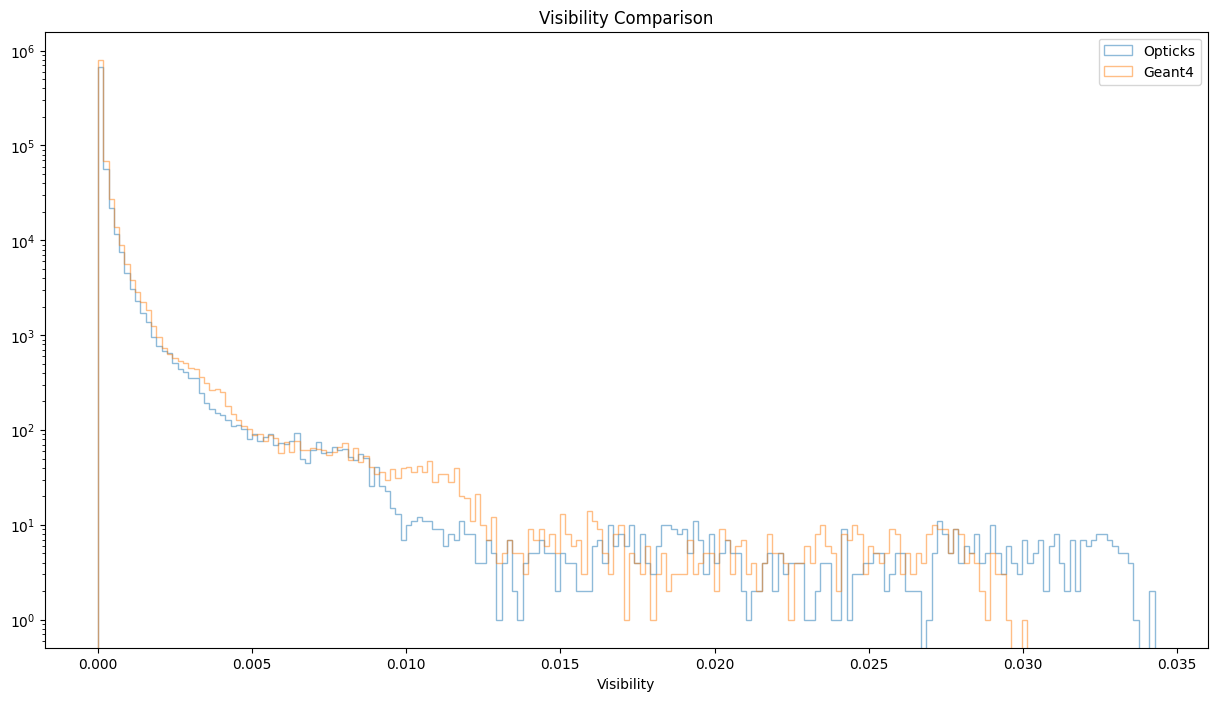

In [16]:
vismin = min(OVisibility[0].min(), G4Visibility[0].min())
vismax = max(OVisibility[0].max(), G4Visibility[0].max())
xbins = np.linspace(vismin , vismax , 200)
plt.figure(figsize=(15,8))
plt.title("Visibility Comparison")
h1=plt.hist(OVisibility[0], bins=xbins, alpha=0.5, label="Opticks",histtype="step")
h2=plt.hist(G4Visibility[0], bins=xbins, alpha=0.5, label="Geant4",histtype="step")
plt.legend()
plt.semilogy()
plt.xlabel("Visibility")    

In [17]:
isSafeFiles=False

/tmp/rice/opticks/ipykernel_3204377/4235995591.py:126: RuntimeWarning: divide by zero encountered in divide
  result  = counts2 / counts1
/tmp/rice/opticks/ipykernel_3204377/4235995591.py:128: RuntimeWarning: invalid value encountered in divide
  res_err = result * np.sqrt((err2 / counts2)**2 + (err1 / counts1)**2)


 Size Bin_Centers is 49
 Size result 49 min, max inf , 0.25396825396825395
 Size res_err 49 min, max nan , nan


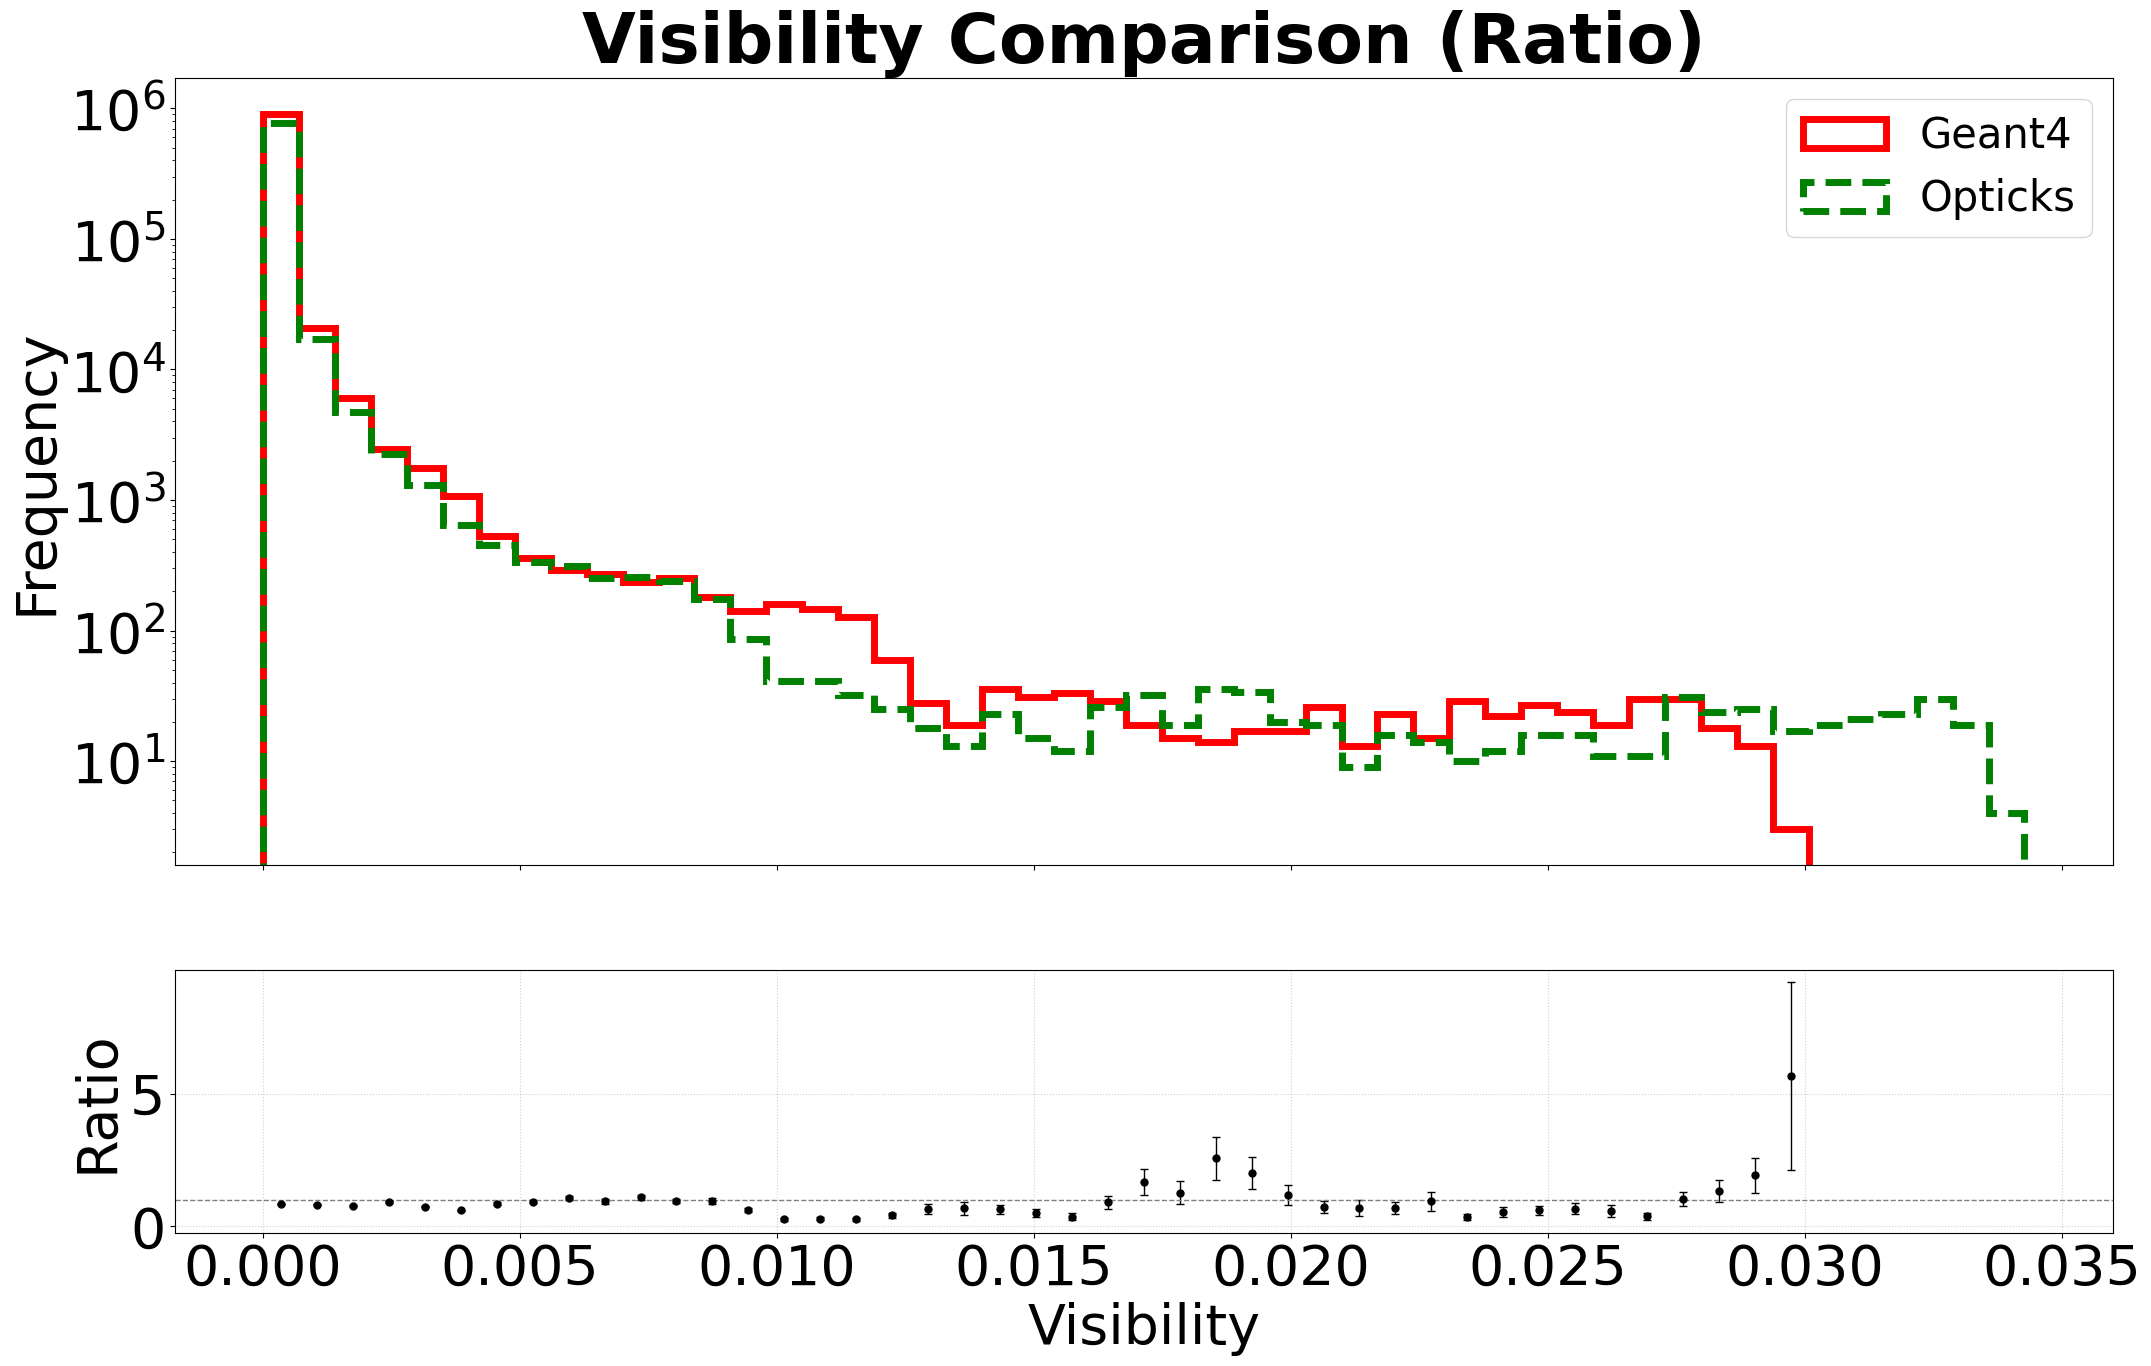

In [18]:
_=Plot1D_KDE(OVisibility[0],G4Visibility[0],"Visibility_Comparison","Visibility Comparison (Ratio)",Binsize=50,labelx="Visibility",isPlottext=False,isHistType="",opacity=1,fontsize=30,width=5,lbl="x(mm)",tp="ratio")

 Size Bin_Centers is 49
 Size result 49 min, max 0.9742554329825992 , 0.7767037977742348
 Size res_err 49 min, max 0.003530498374177208 , 0.0018839154863983252


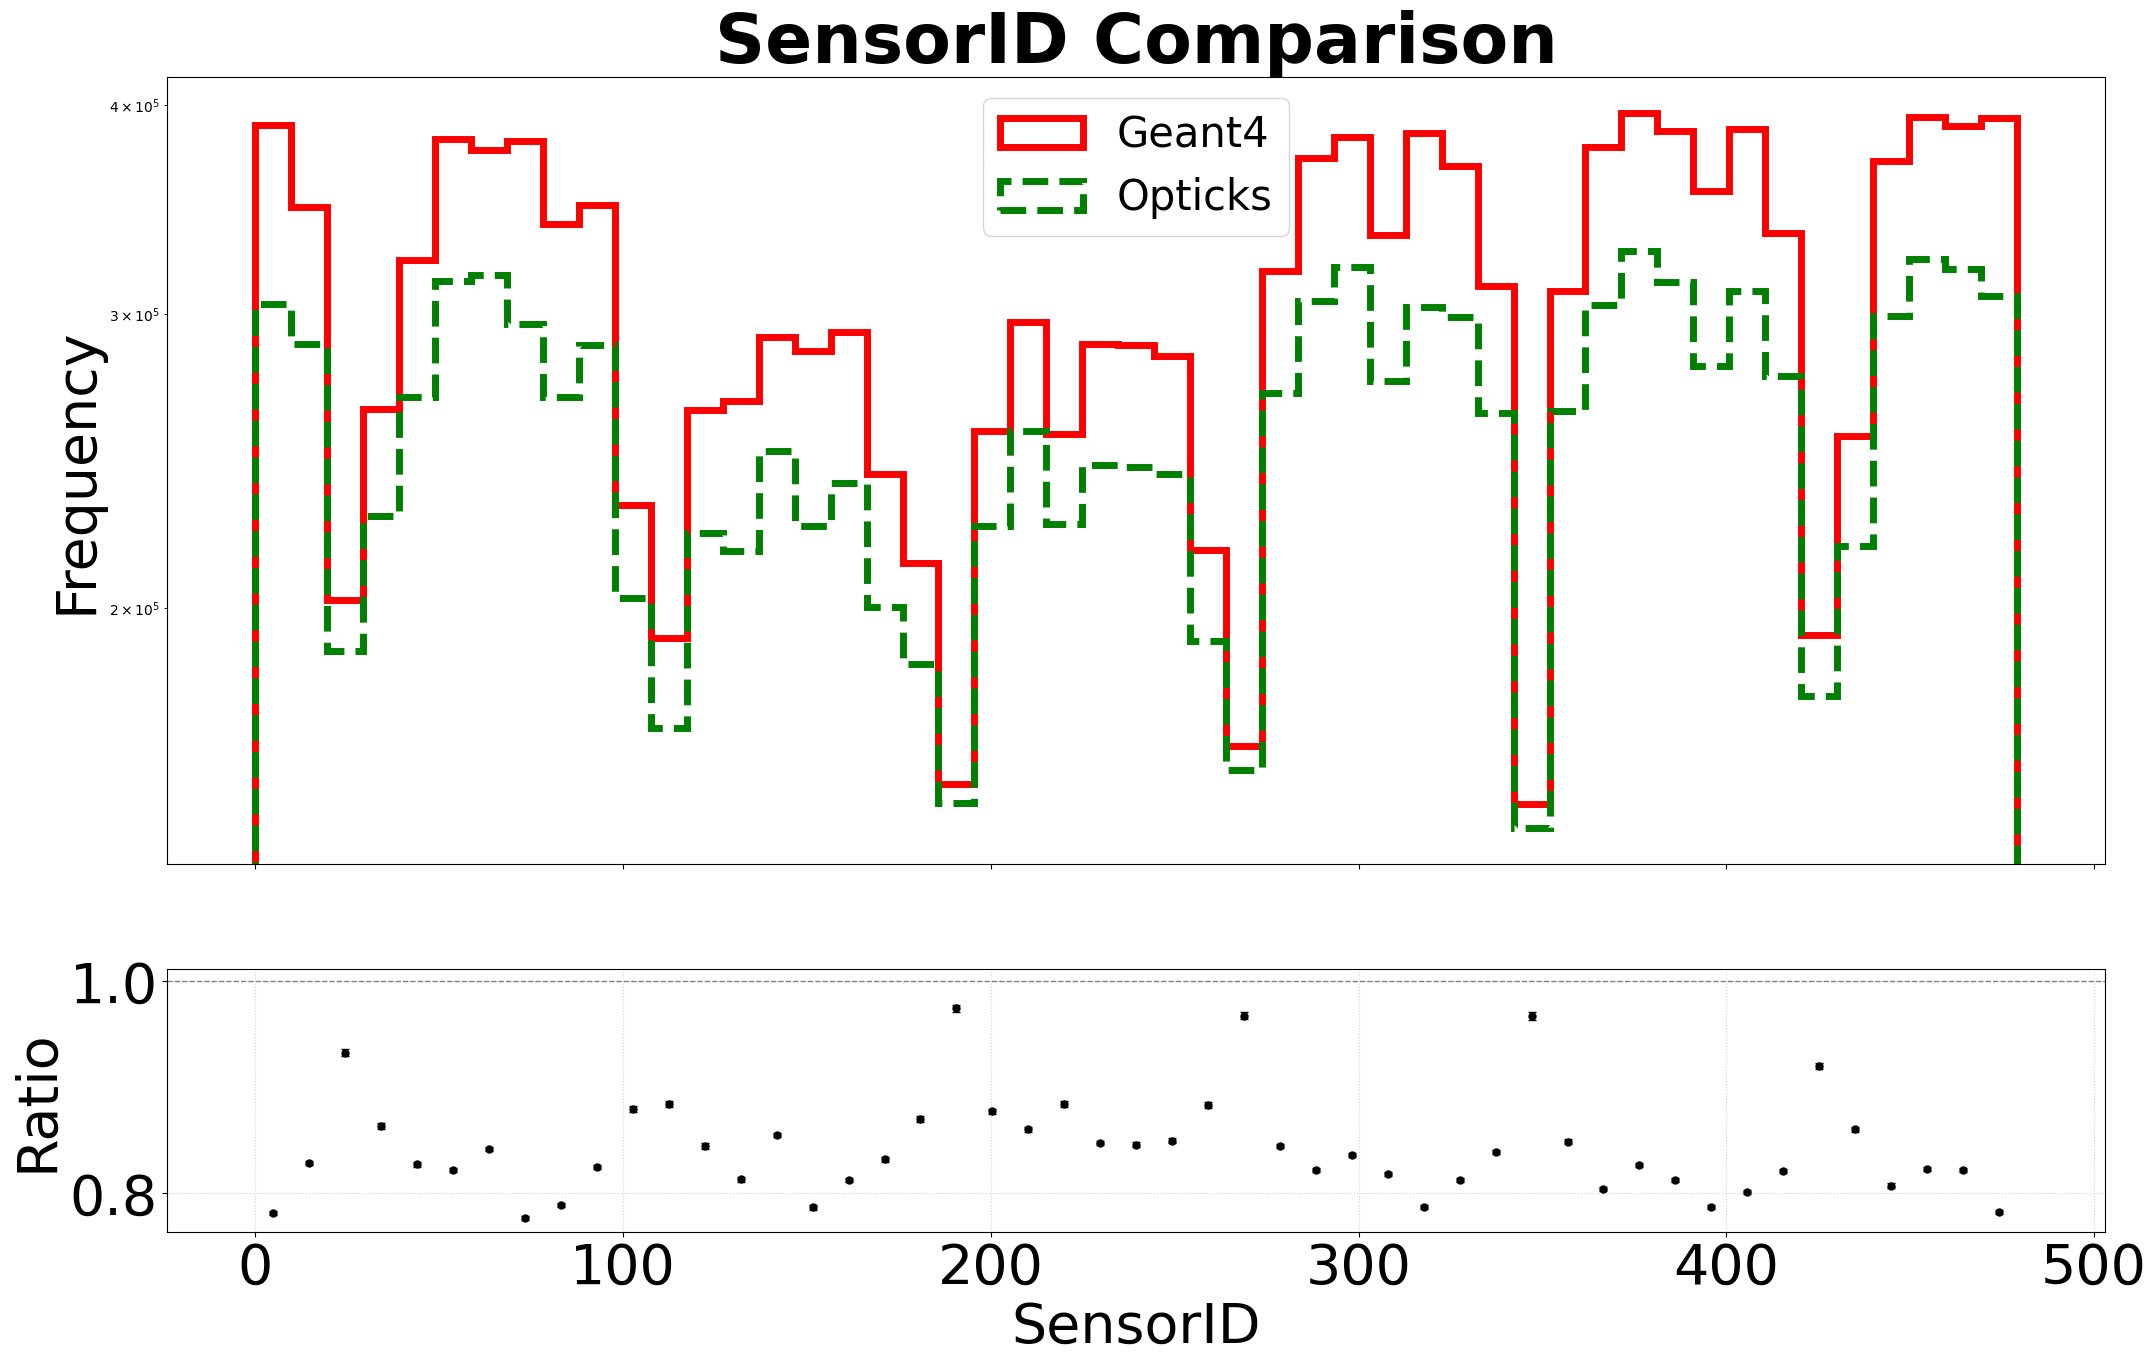

In [19]:
_=Plot1D_KDE(OptSID,G4SID,"SensorID_Comparison","SensorID Comparison",Binsize=50,labelx="SensorID",isPlottext=False,isHistType="",opacity=1,fontsize=30,width=5,lbl="x(mm)",tp="ratio")